# Chapter 11. Training Deep Neural Networks

## Glorot Initialization and He Initialization

In [1]:
import torch
import torch.nn as nn
layer = nn.Linear(40, 10)
layer.weight.data *= 6 ** 0.5
 # Kaiming init (or 3 ** 0.5 for LeCun init)
torch.zero_(layer.bias.data)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [2]:
layer = nn.Linear(40, 10)
nn.init.kaiming_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)

In [3]:

def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model = nn.Sequential(nn.Linear(50, 40), nn.ReLU(), nn.Linear(40, 1), nn.ReLU())
model.apply(use_he_init)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=1, bias=True)
  (3): ReLU()
)

In [4]:
model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=0.2))
model.apply(use_he_init)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
)

### Better Activation Functions

### Leaky ReLU

In [5]:
torch.manual_seed(42)
alpha = 0.2
model = nn.Sequential(nn.Linear(50, 40), nn.LeakyReLU(negative_slope=alpha))
nn.init.kaiming_uniform_(model[0].weight, alpha, nonlinearity="leaky_relu")
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

### ELU and SELU

> Implementing ELU in PyTorch is trivial, just add an ELU layer after each Linear layer in your model, and make sure to use Kaiming initialization for these Linear layers

In [6]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), nn.ELU())
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

> By default, the SELU hyperparameters (scale and alpha) are tuned in such a way that the mean output of each neuron remains close to 0, and the standard deviation remains close to 1 (assuming the inputs are standardized with mean 0 and standard deviation 1 too, and other constraints are respected, as explained in the book). Using this activation function, even a 1,000 layer deep neural network preserves roughly mean 0 and standard deviation 1 across all layers, avoiding the exploding/vanishing gradients problem

In [7]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 40), nn.SELU())
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

### GELU, Swish, SwiGLU, Mish, and RELU2

> SwiGLU

In [8]:
class SwiGLU(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta

    def forward(self, x):
        z1, z2 = x.chunk(2, dim=-1)
        param_swish = z1 * torch.sigmoid(self.beta * z1)
        return param_swish * z2

torch.manual_seed(42)
model = nn.Sequential(nn.Linear(50, 2 * 40), SwiGLU(beta=0.2))
nn.init.kaiming_uniform_(model[0].weight)
model(torch.rand(2, 50)).shape

torch.Size([2, 40])

> RELU(Square)

## Batch Normalization

In [9]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1 * 28 * 28),
    nn.Linear(1 * 28 * 28, 300),
    nn.ReLU(),
    nn.BatchNorm1d(300),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100, 10)
)

In [10]:
dict(model[1].named_parameters()).keys()

dict_keys(['weight', 'bias'])

In [11]:
dict(model[1].named_buffers()).keys()

dict_keys(['running_mean', 'running_var', 'num_batches_tracked'])

> Quite often, applying BN before the activation function works better. Moreover, the Linear layer before a BatchNorm1d layer does not need to have bias terms, since the BatchNorm1d layer has some as well. So you can set bias=False when creating those layers:

In [12]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 300, bias=False),
    nn.BatchNorm1d(300),
    nn.ReLU(),
    nn.Linear(300, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

### Layer Normalization

In [13]:
torch.manual_seed(42)

inputs = torch.randn(32, 3, 100, 200)  # a batch of random RGB images
layer_norm = nn.LayerNorm([100, 200])
result = layer_norm(inputs)  # normalizes over the last two dimensions

In [14]:
means = inputs.mean(dim=[2, 3], keepdim=True)
vars_ = inputs.var(dim=[2, 3], keepdim=True, unbiased=False)
stds = torch.sqrt(vars_ + layer_norm.eps)
result2 = layer_norm.weight * (inputs - means) / stds + layer_norm.bias
assert torch.allclose(result, result2)

In [15]:
layer_norm = nn.LayerNorm([3, 100, 200])
result = layer_norm(inputs)  # normalizes over the last three dimensions

## Gradient Clipping

> See the line nn.utils.clip_grad_norm_(...) in the training function in the next section.

## Reusing Pretrained Layers

### Transfer Learning with PyTorch

## Let's split the fashion MNIST training set in two:

> X_train_A: all images of all items except for T-shirts/tops and pullovers (classes 0 and 2).

> X_train_B: a much smaller training set of just the first 20 images of T-shirts/tops and pullovers.
The validation set and the test set are also split this way, but without restricting the number of images.

We will train a model on set A (classification task with 8 classes), and try to reuse it to tackle set B (binary classification). We hope to transfer a little bit of knowledge from task A to task B, since classes in set A (trousers, dresses, coats, sandals, shirts, sneakers, bags, and ankle boots) are somewhat similar to classes in set B (T-shirts/tops and pullovers). However, since we are using Linear layers, only patterns that occur at the same location can be reused (in contrast, convolutional layers will transfer much better, since learned patterns can be detected anywhere on the image, as we will see in the chapter 12).

Let's fetch the Fashion MNIST data and split it into datasets A and B:

In [16]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28, 28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))
in_B = (y == 0) | (y == 2)  # Pullover or T-shirt/top
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))  # [1,3,4,5,6,7,8,9] => [0,..,7]
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1, 1)

train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7000])
valid_set_A = TensorDataset(X_A[-7_000:-5000], y_A[-7000:-5000])
test_set_A = TensorDataset(X_A[-5_000:], y_A[-5000:])
train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5000], y_B[20:5000])
test_set_B = TensorDataset(X_B[5_000:], y_B[5000:])

train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)

In [17]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
            n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            # Uncomment to activate gradient clipping:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                f"train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [19]:
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
)
model_A = model_A.to(device)

In [20]:
model_A.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)

In [21]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(device)
history_A = train(model_A, optimizer, xentropy, accuracy,
                    train_loader_A, valid_loader_A, n_epochs)

Epoch 1/20, train loss: 0.8446, train metric: 0.7226, valid metric: 0.8375
Epoch 2/20, train loss: 0.4401, train metric: 0.8572, valid metric: 0.8615
Epoch 3/20, train loss: 0.3699, train metric: 0.8752, valid metric: 0.8740
Epoch 4/20, train loss: 0.3357, train metric: 0.8852, valid metric: 0.8770
Epoch 5/20, train loss: 0.3138, train metric: 0.8908, valid metric: 0.8860
Epoch 6/20, train loss: 0.2989, train metric: 0.8963, valid metric: 0.8905
Epoch 7/20, train loss: 0.2868, train metric: 0.9005, valid metric: 0.8840
Epoch 8/20, train loss: 0.2770, train metric: 0.9037, valid metric: 0.8970
Epoch 9/20, train loss: 0.2690, train metric: 0.9077, valid metric: 0.8960
Epoch 10/20, train loss: 0.2614, train metric: 0.9106, valid metric: 0.8945
Epoch 11/20, train loss: 0.2563, train metric: 0.9115, valid metric: 0.9005
Epoch 12/20, train loss: 0.2503, train metric: 0.9143, valid metric: 0.9000
Epoch 13/20, train loss: 0.2455, train metric: 0.9149, valid metric: 0.9035
Epoch 14/20, train lo

In [22]:
torch.manual_seed(9)

model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
).to(device)

In [23]:
model_B.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)

In [24]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B, optimizer, xentropy, accuracy,
                    train_loader_B, valid_loader_B, n_epochs)


Epoch 1/20, train loss: 0.8611, train metric: 0.4000, valid metric: 0.4998
Epoch 2/20, train loss: 0.8415, train metric: 0.4000, valid metric: 0.4944
Epoch 3/20, train loss: 0.8232, train metric: 0.4000, valid metric: 0.4938
Epoch 4/20, train loss: 0.8053, train metric: 0.4500, valid metric: 0.4954
Epoch 5/20, train loss: 0.7879, train metric: 0.4500, valid metric: 0.5060
Epoch 6/20, train loss: 0.7713, train metric: 0.5000, valid metric: 0.5155
Epoch 7/20, train loss: 0.7553, train metric: 0.5500, valid metric: 0.5163
Epoch 8/20, train loss: 0.7400, train metric: 0.6000, valid metric: 0.5227
Epoch 9/20, train loss: 0.7253, train metric: 0.6000, valid metric: 0.5139
Epoch 10/20, train loss: 0.7113, train metric: 0.6000, valid metric: 0.5193
Epoch 11/20, train loss: 0.6977, train metric: 0.4500, valid metric: 0.5267
Epoch 12/20, train loss: 0.6846, train metric: 0.4500, valid metric: 0.5297
Epoch 13/20, train loss: 0.6716, train metric: 0.4500, valid metric: 0.5530
Epoch 14/20, train lo

In [25]:
evaluate_tm(model_B, test_loader_B, accuracy)


tensor(0.7310, device='cuda:0')

In [26]:
import copy

torch.manual_seed(43)
reused_layers = copy.deepcopy(model_A[:-1])
model_B_on_A = nn.Sequential(
    *reused_layers,
    nn.Linear(100, 1)  # new output layer for task B
).to(device)

In [27]:
for layer in model_B_on_A[:-1]:
    for param in layer.parameters():
        param.requires_grad = False

In [28]:
n_epochs = 10
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                    train_loader_B, valid_loader_B, n_epochs)

Epoch 1/10, train loss: 0.7354, train metric: 0.3500, valid metric: 0.4612
Epoch 2/10, train loss: 0.7236, train metric: 0.3500, valid metric: 0.4857
Epoch 3/10, train loss: 0.7119, train metric: 0.3500, valid metric: 0.5133
Epoch 4/10, train loss: 0.7005, train metric: 0.4000, valid metric: 0.5406
Epoch 5/10, train loss: 0.6892, train metric: 0.4000, valid metric: 0.5679
Epoch 6/10, train loss: 0.6780, train metric: 0.4000, valid metric: 0.5968
Epoch 7/10, train loss: 0.6670, train metric: 0.4500, valid metric: 0.6225
Epoch 8/10, train loss: 0.6562, train metric: 0.4500, valid metric: 0.6468
Epoch 9/10, train loss: 0.6455, train metric: 0.5000, valid metric: 0.6669
Epoch 10/10, train loss: 0.6350, train metric: 0.6000, valid metric: 0.6878


In [29]:
for layer in model_B_on_A[2:]:
    for param in layer.parameters():
        param.requires_grad = True

In [30]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                    train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 0.6247, train metric: 0.6500, valid metric: 0.7096
Epoch 2/20, train loss: 0.6124, train metric: 0.7000, valid metric: 0.7291
Epoch 3/20, train loss: 0.6003, train metric: 0.7000, valid metric: 0.7448
Epoch 4/20, train loss: 0.5884, train metric: 0.8500, valid metric: 0.7616
Epoch 5/20, train loss: 0.5768, train metric: 0.9000, valid metric: 0.7739
Epoch 6/20, train loss: 0.5655, train metric: 0.9000, valid metric: 0.7894
Epoch 7/20, train loss: 0.5544, train metric: 0.9000, valid metric: 0.8036
Epoch 8/20, train loss: 0.5435, train metric: 0.9000, valid metric: 0.8112
Epoch 9/20, train loss: 0.5328, train metric: 0.9000, valid metric: 0.8227
Epoch 10/20, train loss: 0.5222, train metric: 0.9000, valid metric: 0.8327
Epoch 11/20, train loss: 0.5119, train metric: 0.9500, valid metric: 0.8398
Epoch 12/20, train loss: 0.5018, train metric: 0.9500, valid metric: 0.8460
Epoch 13/20, train loss: 0.4918, train metric: 0.9500, valid metric: 0.8520
Epoch 14/20, train lo

In [31]:
evaluate_tm(model_B_on_A, test_loader_B, accuracy)

tensor(0.8884, device='cuda:0')

## Faster Optimizers

In [32]:
# extra code – a little function to test an optimizer on Fashion MNIST

train_set = TensorDataset(X[:55_000], y[:55_000])
valid_set = TensorDataset(X[55_000:60_000], y[55_000:60_000])
test_set = TensorDataset(X[60_000:], y[60_000:])

def build_model(seed=42):
    torch.manual_seed(seed)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 10)
    ).to(device)
    model.apply(use_he_init)
    return model

def test_optimizer(model, optimizer, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    history = train(model, optimizer, xentropy, accuracy.to(device),
                    train_loader, valid_loader, n_epochs)
    return history, evaluate_tm(model, test_loader, accuracy)

In [33]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
history_sgd, acc_sgd = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 0.6311, train metric: 0.7795, valid metric: 0.8328
Epoch 2/10, train loss: 0.4495, train metric: 0.8410, valid metric: 0.8500
Epoch 3/10, train loss: 0.4025, train metric: 0.8563, valid metric: 0.8578
Epoch 4/10, train loss: 0.3748, train metric: 0.8656, valid metric: 0.8656
Epoch 5/10, train loss: 0.3541, train metric: 0.8736, valid metric: 0.8646
Epoch 6/10, train loss: 0.3372, train metric: 0.8781, valid metric: 0.8698
Epoch 7/10, train loss: 0.3236, train metric: 0.8825, valid metric: 0.8754
Epoch 8/10, train loss: 0.3125, train metric: 0.8865, valid metric: 0.8754
Epoch 9/10, train loss: 0.3022, train metric: 0.8894, valid metric: 0.8716
Epoch 10/10, train loss: 0.2932, train metric: 0.8932, valid metric: 0.8808


## Momentum

In [34]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), momentum=0.9, lr=0.05)
history_momentum, acc_momentum = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 0.5669, train metric: 0.7977, valid metric: 0.7946
Epoch 2/10, train loss: 0.4523, train metric: 0.8371, valid metric: 0.8438
Epoch 3/10, train loss: 0.4104, train metric: 0.8551, valid metric: 0.8512
Epoch 4/10, train loss: 0.3860, train metric: 0.8615, valid metric: 0.8540
Epoch 5/10, train loss: 0.3681, train metric: 0.8696, valid metric: 0.8604
Epoch 6/10, train loss: 0.3583, train metric: 0.8732, valid metric: 0.8638
Epoch 7/10, train loss: 0.3423, train metric: 0.8760, valid metric: 0.8714
Epoch 8/10, train loss: 0.3350, train metric: 0.8808, valid metric: 0.8694
Epoch 9/10, train loss: 0.3256, train metric: 0.8820, valid metric: 0.8730
Epoch 10/10, train loss: 0.3192, train metric: 0.8872, valid metric: 0.8596


## Nesterov Accelerated Gradient

In [35]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(),
                            momentum=0.9, nesterov=True, lr=0.05)
history_nesterov, acc_nesterov = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 0.5278, train metric: 0.8101, valid metric: 0.8232
Epoch 2/10, train loss: 0.4274, train metric: 0.8473, valid metric: 0.8498
Epoch 3/10, train loss: 0.3924, train metric: 0.8600, valid metric: 0.8460
Epoch 4/10, train loss: 0.3700, train metric: 0.8674, valid metric: 0.8660
Epoch 5/10, train loss: 0.3553, train metric: 0.8716, valid metric: 0.8702
Epoch 6/10, train loss: 0.3426, train metric: 0.8765, valid metric: 0.8652
Epoch 7/10, train loss: 0.3304, train metric: 0.8812, valid metric: 0.8662
Epoch 8/10, train loss: 0.3218, train metric: 0.8842, valid metric: 0.8656
Epoch 9/10, train loss: 0.3136, train metric: 0.8873, valid metric: 0.8658
Epoch 10/10, train loss: 0.3069, train metric: 0.8896, valid metric: 0.8694


## AdaGrad

In [36]:
model = build_model()  # extra code
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.05)
history_adagrad, acc_adagrad = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 0.6062, train metric: 0.8071, valid metric: 0.8538
Epoch 2/10, train loss: 0.3783, train metric: 0.8613, valid metric: 0.8608
Epoch 3/10, train loss: 0.3435, train metric: 0.8729, valid metric: 0.8612
Epoch 4/10, train loss: 0.3244, train metric: 0.8814, valid metric: 0.8734
Epoch 5/10, train loss: 0.3093, train metric: 0.8853, valid metric: 0.8698
Epoch 6/10, train loss: 0.2983, train metric: 0.8900, valid metric: 0.8782
Epoch 7/10, train loss: 0.2871, train metric: 0.8945, valid metric: 0.8810
Epoch 8/10, train loss: 0.2791, train metric: 0.8973, valid metric: 0.8770
Epoch 9/10, train loss: 0.2719, train metric: 0.8987, valid metric: 0.8822
Epoch 10/10, train loss: 0.2662, train metric: 0.9017, valid metric: 0.8820


## RMSProp

In [37]:
model = build_model()  # extra code
optimizer = torch.optim.RMSprop(model.parameters(), alpha=0.9, lr=0.05)
history_rmsprop, acc_rmsprop = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 3.4591, train metric: 0.4727, valid metric: 0.5124
Epoch 2/10, train loss: 1.5703, train metric: 0.4690, valid metric: 0.4390
Epoch 3/10, train loss: 1.3458, train metric: 0.5062, valid metric: 0.5390
Epoch 4/10, train loss: 1.4480, train metric: 0.4928, valid metric: 0.4974
Epoch 5/10, train loss: 1.4260, train metric: 0.4726, valid metric: 0.4288
Epoch 6/10, train loss: 1.4666, train metric: 0.4298, valid metric: 0.3978
Epoch 7/10, train loss: 1.5196, train metric: 0.3951, valid metric: 0.2802
Epoch 8/10, train loss: 1.6409, train metric: 0.3327, valid metric: 0.3338
Epoch 9/10, train loss: 1.5816, train metric: 0.3738, valid metric: 0.3674
Epoch 10/10, train loss: 1.7163, train metric: 0.3632, valid metric: 0.4244


## Adam

In [38]:
model = build_model()  # extra code
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_adam, acc_adam = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 2.4850, train metric: 0.1009, valid metric: 0.1016
Epoch 2/10, train loss: 2.3097, train metric: 0.0984, valid metric: 0.0934
Epoch 3/10, train loss: 2.3089, train metric: 0.1010, valid metric: 0.1054
Epoch 4/10, train loss: 2.3092, train metric: 0.0996, valid metric: 0.0934
Epoch 5/10, train loss: 2.3090, train metric: 0.1013, valid metric: 0.0980
Epoch 6/10, train loss: 2.3089, train metric: 0.0999, valid metric: 0.0994
Epoch 7/10, train loss: 2.3091, train metric: 0.0977, valid metric: 0.0980
Epoch 8/10, train loss: 2.3094, train metric: 0.0974, valid metric: 0.0980
Epoch 9/10, train loss: 2.3093, train metric: 0.1009, valid metric: 0.0994
Epoch 10/10, train loss: 2.3094, train metric: 0.0973, valid metric: 0.1042


### AdaMax

In [39]:
model = build_model()  # extra code
optimizer = torch.optim.Adamax(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_adamax, acc_adamax = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 0.7450, train metric: 0.7781, valid metric: 0.8218
Epoch 2/10, train loss: 0.4747, train metric: 0.8335, valid metric: 0.8430
Epoch 3/10, train loss: 0.4353, train metric: 0.8459, valid metric: 0.8414
Epoch 4/10, train loss: 0.4225, train metric: 0.8522, valid metric: 0.8542
Epoch 5/10, train loss: 0.4027, train metric: 0.8589, valid metric: 0.8536
Epoch 6/10, train loss: 0.3967, train metric: 0.8619, valid metric: 0.8520
Epoch 7/10, train loss: 0.3855, train metric: 0.8644, valid metric: 0.8596
Epoch 8/10, train loss: 0.3748, train metric: 0.8690, valid metric: 0.8580
Epoch 9/10, train loss: 0.3707, train metric: 0.8710, valid metric: 0.8690
Epoch 10/10, train loss: 0.3637, train metric: 0.8761, valid metric: 0.8564


### NAdam

In [40]:
model = build_model()  # extra code
optimizer = torch.optim.NAdam(model.parameters(), betas=(0.9, 0.999), lr=0.05)
history_nadam, acc_nadam = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 1.4211, train metric: 0.5193, valid metric: 0.5814
Epoch 2/10, train loss: 1.1659, train metric: 0.5397, valid metric: 0.5290
Epoch 3/10, train loss: 1.5566, train metric: 0.4883, valid metric: 0.1054
Epoch 4/10, train loss: 2.3094, train metric: 0.1008, valid metric: 0.0934
Epoch 5/10, train loss: 2.3084, train metric: 0.1013, valid metric: 0.0980
Epoch 6/10, train loss: 2.3084, train metric: 0.0988, valid metric: 0.1016
Epoch 7/10, train loss: 2.3086, train metric: 0.0976, valid metric: 0.0980
Epoch 8/10, train loss: 2.3088, train metric: 0.0991, valid metric: 0.0980
Epoch 9/10, train loss: 2.3087, train metric: 0.1016, valid metric: 0.0994
Epoch 10/10, train loss: 2.3088, train metric: 0.0984, valid metric: 0.1042


### AdamW

In [41]:
model = build_model()  # extra code
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.999),
                                weight_decay=1e-5, lr=0.05)
history_adamw, acc_adamw = test_optimizer(model, optimizer)  # extra code

Epoch 1/10, train loss: 2.4850, train metric: 0.1009, valid metric: 0.1016
Epoch 2/10, train loss: 2.3097, train metric: 0.0984, valid metric: 0.0934
Epoch 3/10, train loss: 2.3089, train metric: 0.1010, valid metric: 0.1054
Epoch 4/10, train loss: 2.3092, train metric: 0.0996, valid metric: 0.0934
Epoch 5/10, train loss: 2.3090, train metric: 0.1013, valid metric: 0.0980
Epoch 6/10, train loss: 2.3089, train metric: 0.0999, valid metric: 0.0994
Epoch 7/10, train loss: 2.3091, train metric: 0.0977, valid metric: 0.0980
Epoch 8/10, train loss: 2.3094, train metric: 0.0974, valid metric: 0.0980
Epoch 9/10, train loss: 2.3093, train metric: 0.1009, valid metric: 0.0994
Epoch 10/10, train loss: 2.3094, train metric: 0.0973, valid metric: 0.1042


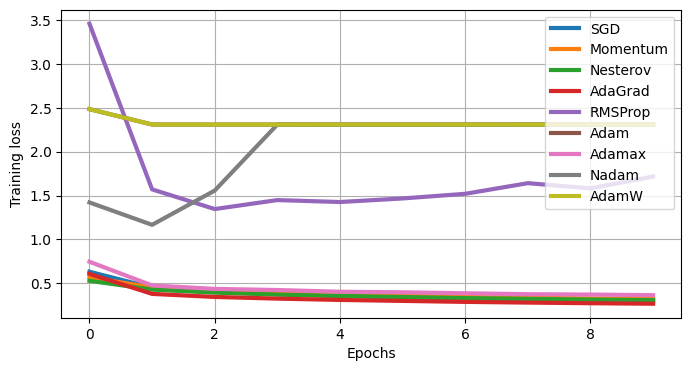

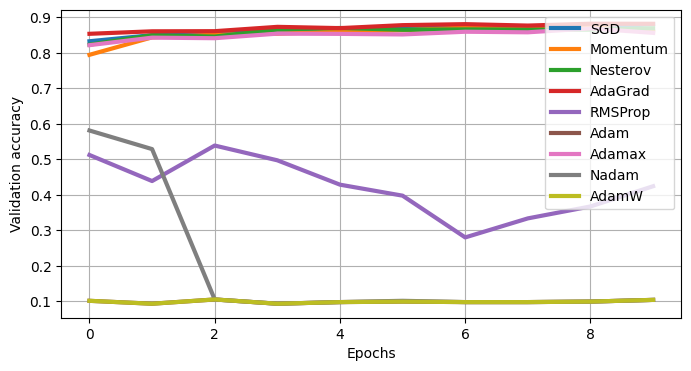

In [42]:
# extra code – visualize the learning curves of all the optimizers
import matplotlib.pyplot as plt
for plot in ("train_losses", "valid_metrics"):
    plt.figure(figsize=(8, 4))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip(
        (history_sgd, history_momentum, history_nesterov, history_adagrad,
            history_rmsprop, history_adam, history_adamax, history_nadam,
            history_adamw), opt_names.split()):
        plt.plot(history[plot], label=opt_name, linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"train_losses": "Training loss", "valid_metrics": "Validation accuracy"}[plot])
    plt.legend(loc="upper right")
    plt.show()

## Learning Rate Scheduling

### Exponential Scheduling

In [43]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
exp_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

In [44]:
import numpy as np

In [45]:
def train_with_scheduler(model, optimizer, loss_fn, metric, train_loader,
                            valid_loader, n_epochs, scheduler):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        losses = []
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                "train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_metric)
        else:
            scheduler.step()
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

def test_scheduler(model, optimizer, scheduler, n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_scheduler(
        model, optimizer, xentropy, metric, train_loader, valid_loader,
        n_epochs, scheduler)
    return history, evaluate_tm(model, test_loader, metric)

In [46]:
history_exp, acc_exp = test_scheduler(model, optimizer, exp_scheduler)  # extra code

Epoch 1/10, train loss: 0.5612, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8548
Learning rate: 0.04500
Epoch 2/10, train loss: 0.3948, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8498
Learning rate: 0.04050
Epoch 3/10, train loss: 0.3537, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8670
Learning rate: 0.03645
Epoch 4/10, train loss: 0.3274, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8718
Learning rate: 0.03281
Epoch 5/10, train loss: 0.3064, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8782
Learning rate: 0.02952
Epoch 6/10, train loss: 0.2902, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8688
Learning rate: 0.02657
Epoch 7/10, train loss: 0.2760, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8808
Learning rate: 0.02391
Epoch 8/10, train loss: 0.2655, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8798
Learning rate: 

### Performance Scheduling

In [47]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1)

In [48]:
history_perf, acc_perf = test_scheduler(model, optimizer, perf_scheduler)  # extra code

Epoch 1/10, train loss: 0.5612, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8548
Learning rate: 0.05000
Epoch 2/10, train loss: 0.3993, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8518
Learning rate: 0.05000
Epoch 3/10, train loss: 0.3603, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8630
Learning rate: 0.05000
Epoch 4/10, train loss: 0.3355, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8690
Learning rate: 0.05000
Epoch 5/10, train loss: 0.3155, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8740
Learning rate: 0.05000
Epoch 6/10, train loss: 0.3012, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8644
Learning rate: 0.05000
Epoch 7/10, train loss: 0.2878, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8780
Learning rate: 0.05000
Epoch 8/10, train loss: 0.2783, train metric: {history['train_metrics'][-1]:.4f}, valid metric: 0.8760
Learning rate: 

### Warming Up the Learning Rate

In [49]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)

In [50]:
# extra code
def train_with_warmup(model, optimizer, loss_fn, metric, train_loader,
                        valid_loader, n_epochs, warmup_scheduler, scheduler):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):

        warmup_scheduler.step()

        # extra code
        losses = []
        metric.reset()

        for X_batch, y_batch in train_loader:

            # extra code
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            losses.append(loss.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(np.mean(losses))
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                f"train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")

        if epoch >= 3:  # deactivate other scheduler(s) during warmup
            scheduler.step(val_metric)

        # extra code
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

def test_warmup_scheduler(model, optimizer, warmup_scheduler, scheduler,
                            n_epochs=10, batch_size=32):
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_set, batch_size=32)
    test_loader = DataLoader(test_set, batch_size=32)
    xentropy = nn.CrossEntropyLoss()
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
    history = train_with_warmup(
        model, optimizer, xentropy, metric, train_loader, valid_loader,
        n_epochs, warmup_scheduler, scheduler)
    return history, evaluate_tm(model, test_loader, metric)

In [51]:
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=2, factor=0.1)
test_warmup_scheduler(model, optimizer, warmup_scheduler, perf_scheduler,
                        n_epochs=10, batch_size=32)   

Epoch 1/10, train loss: 0.6122, train metric: 0.7845, valid metric: 0.8378
Learning rate: 0.00500
Epoch 2/10, train loss: 0.4455, train metric: 0.8389, valid metric: 0.8398
Learning rate: 0.00500
Epoch 3/10, train loss: 0.4000, train metric: 0.8546, valid metric: 0.8546
Learning rate: 0.00500
Epoch 4/10, train loss: 0.3603, train metric: 0.8672, valid metric: 0.8670
Learning rate: 0.05000
Epoch 5/10, train loss: 0.3341, train metric: 0.8773, valid metric: 0.8708
Learning rate: 0.05000
Epoch 6/10, train loss: 0.3172, train metric: 0.8828, valid metric: 0.8666
Learning rate: 0.05000
Epoch 7/10, train loss: 0.3008, train metric: 0.8873, valid metric: 0.8770
Learning rate: 0.05000
Epoch 8/10, train loss: 0.2882, train metric: 0.8923, valid metric: 0.8744
Learning rate: 0.05000
Epoch 9/10, train loss: 0.2794, train metric: 0.8946, valid metric: 0.8768
Learning rate: 0.05000
Epoch 10/10, train loss: 0.2680, train metric: 0.8989, valid metric: 0.8738
Learning rate: 0.00500


({'train_losses': [np.float64(0.6122459134194239),
   np.float64(0.4454744118349784),
   np.float64(0.3999757462155687),
   np.float64(0.3602873729807371),
   np.float64(0.33411205276725525),
   np.float64(0.3171893271762247),
   np.float64(0.3007584758061718),
   np.float64(0.2882173849879794),
   np.float64(0.2793725481221085),
   np.float64(0.2680294385235139)],
  'train_metrics': [0.7844727039337158,
   0.8389272689819336,
   0.8546363711357117,
   0.8672363758087158,
   0.8772545456886292,
   0.8827999830245972,
   0.887290894985199,
   0.8922908902168274,
   0.8946363925933838,
   0.8989090919494629],
  'valid_metrics': [0.8378000259399414,
   0.8398000001907349,
   0.8546000123023987,
   0.8669999837875366,
   0.8708000183105469,
   0.866599977016449,
   0.8769999742507935,
   0.8744000196456909,
   0.876800000667572,
   0.8737999796867371]},
 tensor(0.8709, device='cuda:0'))

### Cosine Annealing with Warm Restarts

In [52]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=0.001)

In [53]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # or any other optim.
cosine_repeat_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=2, T_mult=2, eta_min=0.001)

In [54]:
import re

DOCS_URL = "https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler"
for name in sorted(dir(torch.optim.lr_scheduler)):
    scheduler = getattr(torch.optim.lr_scheduler, name)
    if (not name.startswith("_") and isinstance(scheduler, type) and
        issubclass(scheduler, torch.optim.lr_scheduler.LRScheduler)):
            print(f"• {DOCS_URL}.{name}.html")

• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ChainedScheduler.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ConstantLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingWarmRestarts.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CyclicLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ExponentialLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LRScheduler.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LambdaLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.MultiStepLR.html
• https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.MultiplicativeLR.html
• https://pytorch.org/docs/sta

## Avoiding Overfitting Through Regularization

### ℓ₁ and ℓ₂ regularization

In [55]:
model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, weight_decay=1e-4)
history = test_optimizer(model, optimizer)

Epoch 1/10, train loss: 0.6312, train metric: 0.7792, valid metric: 0.8340
Epoch 2/10, train loss: 0.4513, train metric: 0.8406, valid metric: 0.8488
Epoch 3/10, train loss: 0.4049, train metric: 0.8555, valid metric: 0.8596
Epoch 4/10, train loss: 0.3771, train metric: 0.8656, valid metric: 0.8672
Epoch 5/10, train loss: 0.3568, train metric: 0.8725, valid metric: 0.8670
Epoch 6/10, train loss: 0.3407, train metric: 0.8778, valid metric: 0.8730
Epoch 7/10, train loss: 0.3270, train metric: 0.8814, valid metric: 0.8734
Epoch 8/10, train loss: 0.3164, train metric: 0.8858, valid metric: 0.8788
Epoch 9/10, train loss: 0.3069, train metric: 0.8876, valid metric: 0.8698
Epoch 10/10, train loss: 0.2977, train metric: 0.8915, valid metric: 0.8800


In [56]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name]
for epoch in range(n_epochs):
    total_loss = 0.0
    total_l2_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        main_loss = loss_fn(y_pred, y_batch)
        l2_loss = sum(param.pow(2.0).sum() for param in params_to_regularize)
        loss = main_loss + 1e-4 * l2_loss
        total_loss += loss.item()
        total_l2_loss += l2_loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
            f" – l2 loss: {total_l2_loss / len(train_loader):.3f}"
            f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – l2 loss: 638.392 – loss: 0.626
Epoch 2/3 – l2 loss: 648.236 – loss: 0.466
Epoch 3/3 – l2 loss: 650.651 – loss: 0.426


In [57]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name]
params_bias_and_bn = [
    param for name, param in model.named_parameters()
    if "bias" in name or "bn" in name]
optimizer = torch.optim.SGD([
    {"params": params_to_regularize, "weight_decay": 1e-4},
    {"params": params_bias_and_bn, "weight_decay": 0},
    ], lr=0.05)
for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
            f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – loss: 0.562
Epoch 2/3 – loss: 0.402
Epoch 3/3 – loss: 0.361


In [58]:
n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
params_to_regularize = [
    param for name, param in model.named_parameters()
    if not "bias" in name and not "bn" in name]
for epoch in range(n_epochs):
    total_loss = 0.0
    total_l1_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        main_loss = loss_fn(y_pred, y_batch)
        l1_loss = sum(param.abs().sum() for param in params_to_regularize)
        loss = main_loss + 1e-4 * l1_loss
        total_loss += loss.item()
        total_l1_loss += l1_loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}"
            f" – l1 loss: {total_l1_loss / len(train_loader):.3f}"
            f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – l1 loss: 5711.291 – loss: 1.136
Epoch 2/3 – l1 loss: 5113.138 – loss: 0.920
Epoch 3/3 – l1 loss: 4568.378 – loss: 0.830


## Dropout

In [59]:
torch.manual_seed(42)
model = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(p=0.2), nn.Linear(28 * 28, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 100), nn.ReLU(),
    nn.Dropout(p=0.2), nn.Linear(100, 10)
).to(device)
model.apply(use_he_init)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
history_dropout, acc_dropout = test_optimizer(model, optimizer, batch_size=32)

Epoch 1/10, train loss: 0.7499, train metric: 0.7279, valid metric: 0.8340
Epoch 2/10, train loss: 0.5319, train metric: 0.8085, valid metric: 0.8428
Epoch 3/10, train loss: 0.4894, train metric: 0.8242, valid metric: 0.8542
Epoch 4/10, train loss: 0.4674, train metric: 0.8305, valid metric: 0.8626
Epoch 5/10, train loss: 0.4473, train metric: 0.8383, valid metric: 0.8608
Epoch 6/10, train loss: 0.4347, train metric: 0.8423, valid metric: 0.8692
Epoch 7/10, train loss: 0.4221, train metric: 0.8468, valid metric: 0.8718
Epoch 8/10, train loss: 0.4124, train metric: 0.8506, valid metric: 0.8710
Epoch 9/10, train loss: 0.4057, train metric: 0.8523, valid metric: 0.8738
Epoch 10/10, train loss: 0.3983, train metric: 0.8548, valid metric: 0.8758


### Monte Carlo Dropout

In [60]:
model.eval()
for module in model.modules():
    if isinstance(module, nn.Dropout):
        module.train()

X_new = torch.FloatTensor(fashion_mnist.data[:3].reshape(3, 1, 28, 28) / 255)
X_new = X_new.to(device)

torch.manual_seed(42)
with torch.no_grad():
    X_new_repeated = X_new.repeat_interleave(100, dim=0)
    y_logits_all = model(X_new_repeated).reshape(3, 100, 10)
    y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    y_probas = y_probas_all.mean(dim=1)

In [61]:
y_probas.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0100, 0.0000,
         0.9900],
        [0.9900, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.4600, 0.0300, 0.0400, 0.2300, 0.0500, 0.0000, 0.2000, 0.0000, 0.0000,
         0.0000]], device='cuda:0')

In [62]:
y_std = y_probas_all.std(dim=1)
y_std.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0100, 0.0000,
         0.0100],
        [0.0100, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0100, 0.0000, 0.0000,
         0.0000],
        [0.1800, 0.0400, 0.0400, 0.1400, 0.0700, 0.0000, 0.1000, 0.0100, 0.0000,
         0.0000]], device='cuda:0')

In [64]:
import torch.nn.functional as F

class McDropout(nn.Dropout):
    def forward(self, input):
        return F.dropout(input, self.p, training=True)

In [65]:
def mean_prediction(model, X, n_repeats):
    X_new_repeated = X_new.repeat_interleave(n_repeats, dim=0)
    y_logits = model(X_new_repeated)
    y_logits_all = y_logits.reshape(X.shape[0], n_repeats, *y_logits.shape[1:])
    y_probas_all = torch.nn.functional.softmax(y_logits_all, dim=-1)
    return y_probas_all.mean(dim=1)

In [66]:
with torch.no_grad():
    y_mean_pred = mean_prediction(model, X_new, 100)

y_mean_pred.round(decimals=2)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0200, 0.0000,
         0.9800],
        [0.9900, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0100, 0.0000, 0.0000,
         0.0000],
        [0.4400, 0.0300, 0.0300, 0.2500, 0.0400, 0.0000, 0.2100, 0.0000, 0.0000,
         0.0000]], device='cuda:0')

### Max-Norm Regularization

In [67]:
def apply_max_norm(model, max_norm=2, epsilon=1e-8, dim=1):
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'bias' not in name:
                actual_norm = param.norm(p=2, dim=dim, keepdim=True)
                target_norm = torch.clamp(actual_norm, 0, max_norm)
                param *= target_norm / (epsilon + actual_norm)

In [68]:
torch.manual_seed(42)

n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
loss_fn = nn.CrossEntropyLoss()

model = build_model()  # extra code
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
for epoch in range(n_epochs):
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        model.train()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        apply_max_norm(model)
    print(f"Epoch {epoch + 1}/{n_epochs}"
            f" – loss: {total_loss / len(train_loader):.3f}")

Epoch 1/3 – loss: 0.561
Epoch 2/3 – loss: 0.400
Epoch 3/3 – loss: 0.358


# Chapter 11 Finished